In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
df=pd.read_csv("heart_disease.csv")

df.sample(10)


,age,sex,chest pain type,resting blood pressure,serum cholestoral in mg/dl,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,oldpeak,slope of peak,number of major vessels,thal,Disease
244,51,0,3,140,308,0,2,142,0,1.5,1,1,3,0
136,67,0,3,152,277,0,0,172,0,0.0,1,1,3,0
47,44,1,4,110,197,0,2,177,0,0.0,1,1,3,1
116,46,1,4,120,249,0,2,144,0,0.8,1,0,7,1
238,47,1,3,138,257,0,2,156,0,0.0,1,0,3,0
240,68,1,3,180,274,1,2,150,1,1.6,2,0,7,1
83,41,1,3,130,214,0,2,168,0,2.0,2,0,3,0
133,64,1,4,120,246,0,2,96,1,2.2,3,1,3,1
66,51,1,4,140,261,0,2,186,1,0.0,1,0,3,0
164,43,1,4,110,211,0,0,161,0,0.0,1,0,7,0


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
chest pain type,0
resting blood pressure,0
serum cholestoral in mg/dl,0
fasting blood sugar > 120 mg/dl,0
resting electrocardiographic results,0
maximum heart rate achieved,0
exercise induced angina,0
oldpeak,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral in mg/dl            270 non-null    int64  
 5   fasting blood sugar > 120 mg/dl       270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   maximum heart rate achieved           270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  slope of peak                         270 non-null    int64  
 11  number of major ves

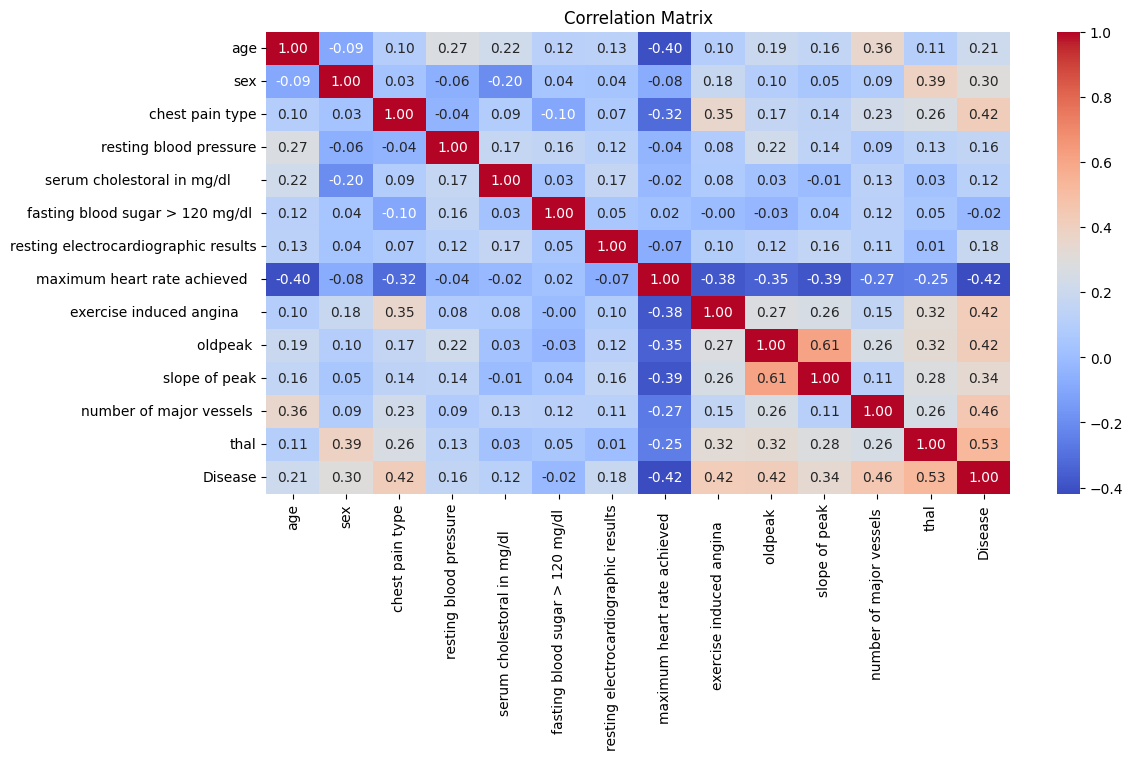

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [ ]:
X=df.drop("Disease",axis=1)
y=df["Disease"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


Lr=Pipeline([
    ("scaler",StandardScaler()),
    ("model1",LogisticRegression(max_iter=500))
    ])
Lr.fit(X_train,y_train)
y_pred=Lr.predict(X_test)

print("Logistic Regression")
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
precission=precision_score(y_test,y_pred)
print("precission",precission)
recall=recall_score(y_test,y_pred)
print("recall :",recall)
f1=f1_score(y_test,y_pred)
print("f1 score  :" ,f1)



Logistic Regression
Accuracy: 0.8518518518518519
precission 0.7857142857142857
recall : 0.9166666666666666
f1 score  : 0.8461538461538461


In [ ]:
# decison tree
from sklearn.tree import DecisionTreeClassifier

Dt=Pipeline([
    ("scaler",StandardScaler()),
    ("model2",DecisionTreeClassifier(random_state=42))
])
Dt.fit(X_train,y_train)
y_pred=Dt.predict(X_test)

print("Decision Tree")
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
precision=precision_score(y_test,y_pred)
print("precission",precision)
recall=recall_score(y_test,y_pred)
print("recall :",recall)
f1=f1_score(y_test,y_pred)
print("f1 score :",f1)


Decision Tree
Accuracy: 0.7962962962962963
precission 0.7407407407407407
recall : 0.8333333333333334
f1 score : 0.7843137254901961


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

RF=Pipeline([
("scaler",StandardScaler()),
("model3",RandomForestClassifier(
        n_estimators=300,
        random_state=42))
])
RF.fit(X_train,y_train)
y_pred=RF.predict(X_test)

print("Random Forest")
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

precision=precision_score(y_test,y_pred)
print("precission",precision)
recall=recall_score(y_test,y_pred)
print("recall :",recall)
f1=f1_score(y_test,y_pred)
print("f1 score :",f1)



Random Forest
Accuracy: 0.8333333333333334
precission 0.8
recall : 0.8333333333333334
f1 score : 0.8163265306122449


In [ ]:
# kNN
from sklearn.neighbors import KNeighborsClassifier

knn=Pipeline([
    ("scaler",StandardScaler()),
    ("model4",KNeighborsClassifier())
])
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

print("KNN")
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


precision=precision_score(y_test,y_pred)
print("precission",precision)
recall=recall_score(y_test,y_pred)
print("recall :",recall)
f1=f1_score(y_test,y_pred)
print("f1 score :",f1)

KNN
Accuracy: 0.7962962962962963
precission 0.7241379310344828
recall : 0.875
f1 score : 0.7924528301886793


In [ ]:
# KNN with grid search
from sklearn.model_selection import GridSearchCV

knn_with_grid=Pipeline([
    ("scaler",StandardScaler()),
    ("model_5",KNeighborsClassifier())
])

grid_param={
    "model_5__n_neighbors":[2,3,5,7,10],
    "model_5__weights":["uniform","distance"],
    "model_5__p":[1,2]
}

grid_search=GridSearchCV(
    estimator=knn_with_grid,
    param_grid=grid_param,
    cv=5,

)

grid_search.fit(X_train,y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)


Best Parameters: {'model_5__n_neighbors': 7, 'model_5__p': 2, 'model_5__weights': 'uniform'}
Best Cross Validation Accuracy: 0.8562367864693445


In [ ]:

print("KNN with grid seach :")
y_pred=grid_search.predict(X_test)

accuray=accuracy_score(y_test,y_pred)
print("accuracy :",accuray)
precission=precision_score(y_test,y_pred)
print("precission",precission)
recall=recall_score(y_test,y_pred)
print("recall :",recall)
f1=f1_score(y_test,y_pred)
print("f1 score  :" ,f1)

KNN with grid seach :
accuracy : 0.7962962962962963
precission 0.7241379310344828
recall : 0.875
f1 score  : 0.7924528301886793


In [ ]:
#lr_with_Pca
from sklearn.decomposition import PCA

lr_with_pca=Pipeline([
    ("scaler",StandardScaler()),
    ("pca",PCA(n_components=5)),
    ("model_6",LogisticRegression())
])
lr_with_pca.fit(X_train,y_train)
y_pred=lr_with_pca.predict(X_test)

print("Logistic Regression with PCA")
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
precision=precision_score(y_test,y_pred)
print("precission",precision)
recall=recall_score(y_test,y_pred)
print("recall :",recall)


Logistic Regression with PCA
Accuracy: 0.8518518518518519
precission 0.8076923076923077
recall : 0.875


In [ ]:
from sklearn.metrics import f1_score
F1 = f1_score(y_test, y_pred)
print("F1 Score:", F1)

F1 Score: 0.84


Among all the models, Logistic Regression achieved the best performance with an Accuracy of 85.19%, Recall of 91.67%, and F1 Score of 84.62%. Random Forest also performed well but was slightly behind Logistic Regression. Logistic Regression with PCA achieved the same accuracy while reducing feature dimensions, showing that PCA preserved most of the important information. Decision Tree and KNN produced comparatively lower performance. Therefore, Logistic Regression was selected as the best model for this dataset because it provided the highest overall classification performance.

🥇 Best Overall: Logistic Regression

কারণ:

Highest Accuracy = 85.19%
Highest Recall = 91.67%
Highest F1 Score = 84.62%

এটি সবচেয়ে বেশি positive case সঠিকভাবে detect করতে পেরেছে।

🥈 Second Best: Logistic Regression + PCA
Accuracy একই (85.19%)
Precision একটু বেশি (80.77%)
F1 Score খুব কাছাকাছি (84.00%)

PCA ব্যবহার করেও accuracy কমেনি। এর মানে PCA feature কমিয়েও গুরুত্বপূর্ণ তথ্য ধরে রাখতে পেরেছে।

🥉 Third: Random Forest
Accuracy = 83.33%
Precision = 80%
Recall = 83.33%
F1 = 81.63%